[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-4/research-assistant.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239974-lesson-4-research-assistant)

# Research Assistant

## 回顧

我們已經涵蓋了幾個 LangGraph 的主要主題：

* Memory
* Human-in-the-loop
* Controllability（可控性）

現在，我們要把這些概念整合起來，來處理 AI 最熱門的應用之一：研究自動化（research automation）。

研究通常是費力的工作，常被外包給分析師。AI 在協助這類工作上有相當大的潛力。

然而，研究需要客製化：原始的 LLM 輸出往往不太適合真實世界的決策工作流程。

客製化、以 AI 為基礎的[研究與報告生成](https://jxnl.co/writing/2024/06/05/predictions-for-the-future-of-rag/#reports-over-rag)工作流程，是解決這個問題的一條有前景的途徑。

## 目標

我們的目標是圍繞 chat model 建立一個輕量的 multi-agent 系統，用來客製化研究流程。

`Source Selection`（來源選擇）
* 使用者可以為他們的研究選擇任意一組輸入來源。
  
`Planning`（規劃）
* 使用者提供一個 topic，系統便會產生一組 AI 分析師（analyst），每位各自聚焦於一個 sub-topic。
* 在研究開始前，我們會用 `Human-in-the-loop` 來修正這些 sub-topic。
  
`LLM Utilization`（LLM 運用）
* 每位分析師會使用所選來源，對一位 AI 專家進行深入訪談。
* 這場訪談會是一段多輪對話，藉此萃取出詳盡的洞見，如同 [STORM](https://arxiv.org/abs/2402.14207) 論文所示。
* 這些訪談會使用具有各自內部 state 的 `sub-graph` 來捕捉。
   
`Research Process`（研究流程）
* 專家會 `parallel`（平行）地蒐集資訊來回答分析師的問題。
* 而所有訪談都會透過 `map-reduce` 同時進行。

`Output Format`（輸出格式）
* 每場訪談所蒐集到的洞見，會被綜合成一份最終報告。
* 我們會為報告使用可客製化的 prompt，以提供彈性的輸出格式。

![Screenshot 2024-08-26 at 7.26.33 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb164d61c93d48e604091_research-assistant1.png)

In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langchain_community langchain_core tavily-python wikipedia

## 設定（Setup）

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [3]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o", temperature=0) 

我們會使用 [LangSmith](https://docs.langchain.com/langsmith/home) 來做 [tracing](https://docs.langchain.com/langsmith/observability-concepts)。

In [4]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

## 產生分析師（Analysts）：Human-In-The-Loop

建立分析師，並使用 human-in-the-loop 來審查他們。

In [5]:
# ── 這一段在教一件事：怎麼逼 LLM 吐出「結構」而不是吐出散文 ──
#
# 前提揭露（不講這個，下面全是天書）：
# LLM 的原生輸出是一串文字。你叫它「列出三位分析師」，它會回你一段作文，
# 你得自己拿 regex 去剖析——那是地獄，而且 LLM 每次格式還不一樣。
#
# structured output 反過來做：先用 pydantic 宣告「我要的形狀」，
# LangChain 把這個 class 翻譯成 tool schema 餵給 LLM，逼它照格子填答，
# 回來的直接是 Analyst 物件，`.name` `.role` 隨你取用，一行剖析都不用寫。
#
# 類比：不是問對方「介紹一下你自己」讓他自由發揮，是遞一張表格請他填。
# 那些 description= 就是表格上的填寫說明——寫給 LLM 看的，不是寫給人看的。
# description 寫得爛，LLM 就填得爛，這是 prompt 不是註解。
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

class Analyst(BaseModel):
    affiliation: str = Field(
        description="Primary affiliation of the analyst.",
    )
    name: str = Field(
        description="Name of the analyst."
    )
    role: str = Field(
        description="Role of the analyst in the context of the topic.",
    )
    description: str = Field(
        description="Description of the analyst focus, concerns, and motives.",
    )
    # persona 把四個欄位攤平成一段文字，等一下要塞進 prompt。
    # 為什麼要多這層轉換？因為 state 裡存結構化物件（好操作、好驗證），
    # 但 LLM 只吃文字。persona 就是「物件 → prompt」中間的轉接頭。
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

# 為什麼要多包一層 Perspectives，不直接跟 LLM 要 List[Analyst]？
# 因為 structured output 底層走的是 tool call，而 tool 的參數必須是「一個物件」
# （欄位要有名字），不能是裸的陣列。所以標準作法是包一個容器 class，
# 裡面放一個 list 欄位。代價是取值時得寫 analysts.analysts（下個 cell 會看到）——
# 那個看起來很蠢的兩層，原因就在這裡，不是手殘。
class Perspectives(BaseModel):
    analysts: List[Analyst] = Field(
        description="Comprehensive list of analysts with their roles and affiliations.",
    )

# 這是「產生分析師」這張暖身小 graph 專用的 state。
#
# ⚠️ 先講清楚免得等下迷路：這張 graph 是練習場，跑完就丟。
#    cell 33 才會出現真正的主 state ResearchGraphState，前四個欄位跟這裡
#    一字不差。教材的用意是先在小場地把 human-in-the-loop 練熟，再搬去大 graph。
#
# 這四個欄位一個 reducer 都沒有 → 意思是「同一步裡只會有一個 node 寫它」，
# 後寫的直接蓋掉先寫的。判準先記起來，後面會一直用到：
# 要不要 reducer，只看「有沒有人搶著寫同一個 key」。
class GenerateAnalystsState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

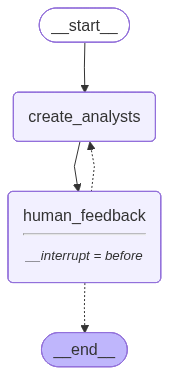

In [6]:
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

def create_analysts(state: GenerateAnalystsState):
    
    """ 建立分析師 """
    
    topic=state['topic']
    max_analysts=state['max_analysts']
    human_analyst_feedback=state.get('human_analyst_feedback', '')
        
    # with_structured_output(Perspectives) 回傳的還是一個 llm，
    # 但它 invoke 完吐出來的不是 AIMessage，是一個貨真價實的 Perspectives 物件。
    # 這就是為什麼下面能直接寫 analysts.analysts，而不用剖析任何文字。
    structured_llm = llm.with_structured_output(Perspectives)

    # System message
    system_message = analyst_instructions.format(topic=topic,
                                                            human_analyst_feedback=human_analyst_feedback, 
                                                            max_analysts=max_analysts)

    # 產生問題 
    analysts = structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content="Generate the set of analysts.")])
    
    # 把分析師清單寫入 state
    return {"analysts": analysts.analysts}

def human_feedback(state: GenerateAnalystsState):
    """ 一個會被中斷（interrupt）的 no-op node """
    # ⚠️ 這個 node 是空的，一個 pass 就結束——這不是漏寫，這是整個設計的關鍵。
    #
    # 它存在的唯一理由，是「當一個可以被停下來的地點」。
    # 下面 compile 時寫 interrupt_before=['human_feedback']，graph 跑到這裡
    # 就會在「執行它之前」煞車。人類在外面用 update_state() 把意見寫進 state，
    # 再假裝那是這個 node 寫的（見 cell 13 的 as_node）。
    #
    # 類比：這是流水線上一個貼著「主管簽名處」的空工位。
    # 工位本身不做任何事，它的價值是「線會停在這裡等人」。
    pass

def should_continue(state: GenerateAnalystsState):
    """ 回傳下一個要執行的 node """
    # 這是整張 graph 的迴圈開關：有意見 → 退回去重做；沒意見 → 收工。
    #
    # 關鍵在於它讀的 human_analyst_feedback 不是任何 node 寫的，
    # 是「人類從 graph 外面塞進來的」。
    # conditional edge 讀外部注入的 state 來決定走向 —— 這就是 human-in-the-loop 的本體。

    # 檢查是否有 human feedback
    human_analyst_feedback=state.get('human_analyst_feedback', None)
    if human_analyst_feedback:
        return "create_analysts"
    
    # 否則結束
    return END

# 加入 node 與 edge 
builder = StateGraph(GenerateAnalystsState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
# ⚠️ 踩雷：第三個參數 ["create_analysts", END] 只是「可能去向」的宣告，供畫圖用，
#    它不會強制 should_continue 只能回傳這兩個。真正決定走向的是回傳值本身。
#    所以 node 名字打錯字是「執行到那一步才炸」，compile 時不會攔你。
builder.add_conditional_edges("human_feedback", should_continue, ["create_analysts", END])

# 編譯
# 下面這兩個參數是同一件事的兩半，缺一不可（同 module-3 breakpoints 章）：
#
#   checkpointer=memory    → 每跑完一個 node 就存檔。
#                            沒有它，graph 停下來 state 沒地方放，人類回來也無從續跑。
#   interrupt_before=[...]  → 指定「跑到 human_feedback 之前先煞車」。
#
# ⚠️ 踩雷：只寫 interrupt_before 卻不給 checkpointer，compile 會直接報錯。
#    它們是綁在一起的：**能停 ⟺ 能存**。停下來的本質就是「存檔後不繼續」。
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

# 檢視
# xray=1 → 連 sub-graph 的內部也一起畫出來。
# 這張 graph 還沒有 sub-graph，所以看不出差別；等 cell 33 的主 graph 才會發威。
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [7]:
# 輸入
max_analysts = 3 
topic = "The benefits of adopting LangGraph as an agent framework"
# thread = 這次研究的「存檔名稱」。所有 checkpoint 都掛在這個 id 底下串成時間線。
# 換一個 thread_id 就是開新存檔，剛剛那些分析師完全不存在。
thread = {"configurable": {"thread_id": "1"}}

# 執行 graph 直到第一次中斷
# ⚠️ 踩雷：這個 for 迴圈看起來像「跑完整張 graph」，其實不是。
#    它跑到 human_feedback 前面就煞車，迴圈自然結束，程式若無其事往下走——
#    沒有例外、沒有警告，安安靜靜就停了。
#    **迴圈跑完 ≠ graph 跑完。** 要確認到底停在哪，得靠下個 cell 的 get_state().next。
for event in graph.stream({"topic":topic,"max_analysts":max_analysts,}, thread, stream_mode="values"):
    # 審查
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Emily Carter
Affiliation: Tech Innovators Inc.
Role: Technology Adoption Specialist
Description: Dr. Carter focuses on the technological advancements and integration of new frameworks like LangGraph. Her primary concern is how these frameworks can enhance efficiency and innovation in software development. She is motivated by the potential of LangGraph to streamline processes and improve the adaptability of agent-based systems.
--------------------------------------------------
Name: Mr. John Smith
Affiliation: Global Business Solutions
Role: Business Strategy Analyst
Description: Mr. Smith analyzes the strategic business benefits of adopting new technologies such as LangGraph. His focus is on the competitive advantage and cost-effectiveness that LangGraph can offer to businesses. He is particularly interested in how LangGraph can drive business growth and improve market positioning.
--------------------------------------------------
Name: Ms. Sarah Lee
Affiliation: Data Secur

In [8]:
# .next 回答的問題是「如果現在續跑，下一個會執行誰」。
# 這裡會印出 ('human_feedback',) → 證明 graph 停在 human_feedback「之前」，
# 也就是這個 node 還沒跑過。
# 印出空的 () 才代表真的跑到底了（cell 18 會看到這個對照）。
state = graph.get_state(thread)
state.next

('human_feedback',)

In [9]:
# as_node="human_feedback" 是這行的靈魂，也是全章最反直覺的一手。
#
# 它的意思是：「這筆 state 更新，請當作是 human_feedback 這個 node 寫的。」
# 為什麼要騙 graph？因為 graph 現在卡在 human_feedback 之前，
# 它必須知道「這一步算誰做的」，才能決定接下來要走哪條 edge——
# 也就是掛在 human_feedback 後面、由 should_continue 決定的那條 conditional edge。
#
# ⚠️ 踩雷：不寫 as_node，這筆更新會被記在「當前位置」名下，
#    續跑時 human_feedback 還是會照跑一次，路由也可能算到別條路上。
#    同 module-3 editing state 章。
graph.update_state(thread, {"human_analyst_feedback": 
                            "Add in someone from a startup to add an entrepreneur perspective"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0ad476-cb07-6cca-8002-853c2969aefa'}}

In [10]:
# ⚠️ stream 的第一個參數是 None —— 這是「續跑」，不是「重跑」。
#
# 一般 Python 直覺會讀成「傳空輸入 → 從頭來一遍」。完全相反。
# None 對 LangGraph 的意思是：「我沒有新輸入，請從 checkpoint 存的位置接下去。」
# 傳 dict 才是「開新的一輪，從 START 開始跑」。
#
# 這一輪實際會發生：跑 human_feedback（空的）→ should_continue 看到有 feedback
# → 回頭再跑一次 create_analysts → 又停在 human_feedback 前面。繞了一圈。
for event in graph.stream(None, thread, stream_mode="values"):
    # 審查
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Emily Carter
Affiliation: Tech Innovators Inc.
Role: Technology Adoption Specialist
Description: Dr. Carter focuses on the technological advancements and integration of new frameworks like LangGraph. Her primary concern is how these frameworks can enhance efficiency and innovation in software development. She is motivated by the potential of LangGraph to streamline processes and improve the adaptability of agent-based systems.
--------------------------------------------------
Name: Mr. John Smith
Affiliation: Global Business Solutions
Role: Business Strategy Analyst
Description: Mr. Smith analyzes the strategic business benefits of adopting new technologies such as LangGraph. His focus is on the competitive advantage and cost-effectiveness that LangGraph can offer to businesses. He is particularly interested in how LangGraph can drive business growth and improve market positioning.
--------------------------------------------------
Name: Ms. Sarah Lee
Affiliation: Data Secur

In [11]:
# 把 human_analyst_feedback 設回 None ＝「我沒意見了，收工吧」。
# 這是離開迴圈的唯一出口：should_continue 讀到 falsy 值就回傳 END。
#
# ⚠️ 踩雷：這裡一定要「明確寫入 None」，不能什麼都不做就直接續跑。
#    因為上一輪的 feedback 還躺在 state 裡，不覆蓋掉的話 should_continue
#    會再看到它，graph 就永遠繞圈出不來。
further_feedack = None
graph.update_state(thread, {"human_analyst_feedback": 
                            further_feedack}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0ad476-f7be-6ff2-8004-8506bc8ccc71'}}

In [12]:
# stream_mode="updates" → 每步只吐「這個 node 改了什麼」，dict 的 key 就是 node 名字。
# 對照組 "values"（上面幾個 cell 用的）→ 每步吐出「完整 state」。
# 這裡只想確認流程走過哪些 node，所以 updates 清爽得多。
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

In [13]:
final_state = graph.get_state(thread)
analysts = final_state.values.get('analysts')

In [14]:
final_state.next

()

In [15]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50) 

Name: Alex Johnson
Affiliation: Tech Innovators Inc.
Role: Startup Entrepreneur
Description: Alex is a co-founder of a tech startup that focuses on developing innovative AI solutions. With a keen interest in leveraging cutting-edge technologies to gain a competitive edge, Alex is particularly interested in how adopting LangGraph as an agent framework can streamline development processes, reduce costs, and accelerate time-to-market for new AI products.
--------------------------------------------------
Name: Dr. Emily Chen
Affiliation: AI Research Institute
Role: AI Researcher
Description: Dr. Chen is a leading researcher in the field of artificial intelligence, with a focus on agent-based systems. Her work involves exploring the theoretical underpinnings and practical applications of AI frameworks. She is interested in the technical benefits of LangGraph, such as its scalability, flexibility, and how it enhances the performance of AI agents in complex environments.
--------------------

## 進行訪談（Conduct Interview）

### 產生問題（Generate Question）

分析師會向專家提出問題。

In [16]:
import operator
from typing import  Annotated
from langgraph.graph import MessagesState

# ══════════════════════════════════════════════════════════════════════
#  三個 State class 的關係圖 —— 這章最容易迷路的地方，先看懂再往下讀
# ══════════════════════════════════════════════════════════════════════
#
#   GenerateAnalystsState   ← cell 9。暖身用的練習場，跑完就丟，
#           │                  不參與最終系統。欄位被下面完整吸收。
#           ▼
#   ResearchGraphState      ← cell 33。**主 state**，整個系統實際跑的是它。
#   ├─ topic / max_analysts / human_analyst_feedback / analysts
#   ├─ sections: Annotated[list, operator.add]  ◄──┐
#   └─ introduction / content / conclusion         │  唯一的橋
#      / final_report                              │
#                                                  │  兩邊同名的 sections，
#   InterviewState          ← 就是這個 cell。      │  就是 sub-graph 與主 graph
#   ├─ messages（繼承自 MessagesState）            │  之間交換資料的唯一管線
#   ├─ max_num_turns                               │
#   ├─ context: Annotated[list, operator.add]      │
#   ├─ analyst / interview                         │
#   └─ sections: list  ────────────────────────────┘
#
#   誰是誰，一句話版本：
#     * 主 state        = ResearchGraphState（外層那張大 graph 用的）
#     * sub-graph state = InterviewState（每一場訪談自己的小宇宙）
#     * Send() 餵的     = InterviewState 的一部分（cell 34 只餵 analyst + messages）
#
# ⚠️ 這章最關鍵的機制：LangGraph 的 sub-graph 靠「**同名欄位**」跟外層通訊。
#    InterviewState 有 sections、ResearchGraphState 也有 sections
#    → 訪談結束時，sections 的值會自動浮上去交給主 graph。
#    而 context / interview / messages 主 state 沒有同名欄位，
#    所以它們一輩子留在訪談內部，外面看不到也不在乎——
#    這正是 sub-graph 的用途：把一整套髒細節關進一個盒子。
#    這就是 sub-graph 章講的那件事，只是這次是真的拿它來蓋系統。
# ══════════════════════════════════════════════════════════════════════

class InterviewState(MessagesState):
    # 繼承 MessagesState = 白拿一個 messages 欄位，而且它自帶 add_messages reducer。
    # 所以下面每個 node 回傳 {"messages": [x]} 都是「附加到對話尾巴」，
    # 不是「把整串對話換成這一句」。訪談的本質就是一段對話，直接站在它肩膀上。
    max_num_turns: int # 訪談最多幾輪（終止條件之一，見 cell 28 的 route_messages）

    # ⚠️ 這裡有 reducer，因為 search_web 和 search_wikipedia 是**平行跑的**，
    #    同一步裡兩個 node 都會回傳 {"context": [...]}。
    #    沒有 operator.add 的話，LangGraph 會直接拋 InvalidUpdateError
    #    （同一步有兩個 node 搶寫同一個沒 reducer 的 key，它不敢猜你要哪個）。
    #    加了它，兩份搜尋結果變成「相加」＝ 兩篇都留下。同 parallelization 章。
    context: Annotated[list, operator.add] # Source docs

    analyst: Analyst # 這場訪談由哪位分析師主持（由 cell 34 的 Send() 從外面餵進來）
    interview: str # 訪談逐字稿（只有 save_interview 一個 node 會寫 → 不用 reducer）

    # 為什麼 sections 在這裡是純 list，到了 ResearchGraphState 就得加 reducer？
    # 判準永遠是那一句「有沒有多個 node 同時寫它」：
    #     在這場訪談內  → 只有 write_section 會寫       → 不用 reducer
    #     在主 graph 裡 → N 場訪談同時交卷寫同一個 key → 非有 reducer 不可
    # 同一個欄位名，兩種身分。這是全章最精緻、也最容易看漏的一手。
    sections: list # Final key we duplicate in outer state for Send() API

# 又一張「請填表」：逼 LLM 把一整段對話濃縮成一句搜尋關鍵字。
# 為什麼不直接叫 LLM 回答就好？因為它會回「好的，我建議搜尋：langgraph agent...」
# 這種夾雜客套話的句子，沒辦法直接餵給 Tavily。
# 用 schema 逼它只給欄位值，拿到的就是乾淨可用的字串。
class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

In [17]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

def generate_question(state: InterviewState):
    """ 產生問題的 node """
    # 這個 node 只做一件事：讓分析師「以自己的人設」問下一個問題。
    #
    # 關鍵在下面的 analyst.persona —— 把分析師身分注入 system prompt，
    # 所以三位分析師問出來的問題會完全不同。
    # 這就是 multi-agent 的「多」到底從哪來：不是三個模型，是同一個模型戴三副面具。

    # 取得 state
    analyst = state["analyst"]
    messages = state["messages"]

    # 產生問題 
    system_message = question_instructions.format(goals=analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
        
    # 回傳 {"messages": [question]}：因為 MessagesState 自帶 add_messages reducer，
    # 這是「把問題附加到對話尾巴」，不是「把整串對話換成這一句」。
    return {"messages": [question]}

### 產生答案（Generate Answer）：Parallelization

專家會平行地從多個來源蒐集資訊來回答問題。

舉例來說，我們可以使用：

* 特定網站，例如透過 [`WebBaseLoader`](https://docs.langchain.com/oss/python/integrations/document_loaders/web_base)
* 已建立索引的文件，例如透過 [RAG](https://docs.langchain.com/oss/python/langchain/retrieval)
* Web search
* Wikipedia search

你可以嘗試不同的 web search 工具，例如 [Tavily](https://tavily.com/)。

In [18]:
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("TAVILY_API_KEY")

In [19]:
# Web search 工具
from langchain_tavily import TavilySearch  # updated 1.0

tavily_search = TavilySearch(max_results=3)

In [20]:
# Wikipedia search 工具
from langchain_community.document_loaders import WikipediaLoader

現在，我們建立 node 來搜尋 web 和 wikipedia。

我們也會建立一個 node 來回答分析師的問題。

最後，我們會建立 node 來儲存完整訪談，並寫出訪談的摘要（「section」）。

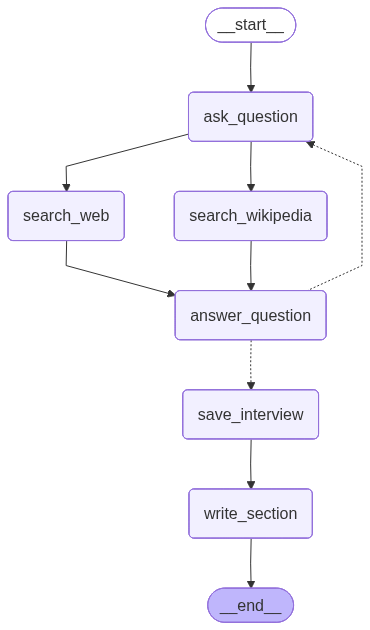

In [21]:
from langchain_core.messages import get_buffer_string

# 撰寫 search query
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.
        
First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query""")

# ── 兩個搜尋 node：parallelization 章在這裡實戰 ──
# search_web 和 search_wikipedia 幾乎是雙胞胎，只差資料來源。
# 它們等一下會被接成「同時從 ask_question 出發」的兩條 edge（見本 cell 最下面的接線），
# LangGraph 看到這個形狀就會在同一步平行執行它們——你不用寫任何 async。
# 兩個都回傳 {"context": [...]}，靠 InterviewState 上的 operator.add 合流。
def search_web(state: InterviewState):
    
    """ 從 web search 取得文件 """

    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    # 搜尋
    #search_docs = tavily_search.invoke(search_query.search_query) # updated 1.0
    data = tavily_search.invoke({"query": search_query.search_query})
    search_docs = data.get("results", data)
    

     # 格式化
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    # ⚠️ 踩雷：回傳的是 [formatted_search_docs]——**包在 list 裡**，不是裸字串。
    #    因為 reducer 是 operator.add：list + list = 兩份都在。
    #    如果漏掉方括號寫成字串，operator.add 會變成「字串相接」，
    #    型別跟 context: list 對不上，而且**不會當場炸**，
    #    要等下游 prompt 讀到怪東西才發現。這種錯最難抓。
    return {"context": [formatted_search_docs]} 

def search_wikipedia(state: InterviewState):
    
    """ 從 wikipedia 取得文件 """

    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    # 搜尋
    search_docs = WikipediaLoader(query=search_query.search_query, 
                                  load_max_docs=2).load()

     # 格式化
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

def generate_answer(state: InterviewState):
    
    """ 回答問題的 node """

    # 取得 state
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # 回答問題
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # 把這個 message 命名為來自專家（expert）
    answer.name = "expert"
    
    # 把它附加到 state
    return {"messages": [answer]}

def save_interview(state: InterviewState):
    
    """ 儲存訪談 """

    # 取得 messages
    messages = state["messages"]
    
    # 把訪談轉成字串
    interview = get_buffer_string(messages)
    
    # 儲存到 interview key
    return {"interview": interview}

# ── 訪談迴圈的煞車：怎麼判斷「問夠了、可以收工」 ──
# 這是整張 sub-graph 唯一的 conditional edge，也是唯一能跳出
# ask_question → search → answer_question → ask_question 這個環的地方。
#
# 兩個終止條件，任一成立就收工：
#   1. 硬上限：專家已經回答滿 max_num_turns 次（預設 2）。
#      ⚠️ 這是保命索。LLM 不保證會自己說結束，沒有這條就是無限迴圈燒 token。
#   2. 軟出口：分析師自己在問題裡說了 "Thank you so much for your help"
#      ——那句話是 cell 22 的 question_instructions 教它講的。
#      也就是：**約定一個暗號，讓 LLM 自己喊停**。這是 agent 常見的收尾手法。
#
# ⚠️ 踩雷：max_num_turns 的預設值 2 是寫在下面 state.get(...,2) 裡的，
#    不是寫在 InterviewState 上。而 cell 34 的 Send() 並沒有餵 max_num_turns，
#    所以正式跑起來時每場訪談都吃這個 2。想改輪數，要改對地方。
def route_messages(state: InterviewState, 
                   name: str = "expert"):

    """ 在提問與回答之間進行路由 """
    
    # 取得 messages
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns',2)

    # 檢查專家回答的次數 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # 如果專家回答超過上限次數就結束
    if num_responses >= max_num_turns:
        return 'save_interview'

    # 為什麼是 messages[-2] 而不是 [-1]？
    # 這個 router 掛在 answer_question 後面，所以此刻對話尾巴長這樣：
    #     [..., 分析師的問題(-2), 專家的回答(-1)]
    # 要檢查暗號的是分析師那句話，所以往回數兩格。
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    return "ask_question"

section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

# ⚠️ 原始教材筆誤：這個 node 的 docstring 寫「回答問題的 node」，
#    是從上面的 generate_answer 複製貼上忘了改。它實際做的是「寫 section」。
#    （不改程式碼，只在這裡點出來，免得學員照著念被誤導。）
#
# 這個 node 是每場訪談的產出口：把一整場訪談壓縮成一段報告 section。
# 注意它餵給 LLM 的是 context（原始來源文件），不是 interview（逐字稿）——
# 所以引用標號才對得上真正的 URL。interview 這個欄位其實只是留個存證。
def write_section(state: InterviewState):

    """ 回答問題的 node """

    # 取得 state
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    # 使用從訪談蒐集到的來源文件（context）或訪談本身（interview）來撰寫 section
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    # 一樣包成 list。在這場訪談裡它只是「一個元素的 list」，看起來多此一舉；
    # 但等這張 sub-graph 被塞進主 graph（cell 33），N 場訪談各自交回的
    # [自己那段] 會被主 state 的 operator.add 串成 [s1, s2, s3]。
    # **這一行就是 map-reduce 裡 map 的產出口。**
    return {"sections": [section.content]}

# 加入 node 與 edge 
interview_builder = StateGraph(InterviewState)
interview_builder.add_node("ask_question", generate_question)
interview_builder.add_node("search_web", search_web)
interview_builder.add_node("search_wikipedia", search_wikipedia)
interview_builder.add_node("answer_question", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("write_section", write_section)

# 流程
#   ask_question →（search_web ‖ search_wikipedia 平行）→ answer_question
#               → route_messages 判斷 → 回去再問 or 收工
#               → save_interview → write_section → END
interview_builder.add_edge(START, "ask_question")
# 一個 node 拉出兩條 edge = fan-out（分頭去辦）；
# 兩個 node 指向同一個 node = fan-in（等兩邊都回來才繼續）。
# LangGraph 光看這四行的形狀就知道要平行跑，而且會等兩邊都跑完才進 answer_question。
# 這就是 parallelization 章的圖形，只是這次兩條腿是真的在查不同的資料庫。
interview_builder.add_edge("ask_question", "search_web")
interview_builder.add_edge("ask_question", "search_wikipedia")
interview_builder.add_edge("search_web", "answer_question")
interview_builder.add_edge("search_wikipedia", "answer_question")
interview_builder.add_conditional_edges("answer_question", route_messages,['ask_question','save_interview'])
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)

# 訪談
# with_config(run_name="Conduct Interviews") 純粹是給 LangSmith 看的標籤。
# 三場訪談平行跑的時候，trace 上不標名字，你根本分不出哪條線是誰。
#
# ⚠️ 這裡給的 checkpointer 只服務「單獨測試這張 sub-graph」（cell 31）。
#    等 cell 33 把它塞進主 graph 時，用的是 interview_builder.compile()——
#    刻意不帶 checkpointer，因為 sub-graph 會直接繼承主 graph 的，
#    這樣整個系統才只有一條 checkpoint 時間線，而不是各存各的。
memory = MemorySaver()
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name="Conduct Interviews")

# 檢視
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [22]:
# 挑一位分析師
analysts[0]

Analyst(affiliation='Tech Innovators Inc.', name='Alex Johnson', role='Startup Entrepreneur', description='Alex is a co-founder of a tech startup that focuses on developing innovative AI solutions. With a keen interest in leveraging cutting-edge technologies to gain a competitive edge, Alex is particularly interested in how adopting LangGraph as an agent framework can streamline development processes, reduce costs, and accelerate time-to-market for new AI products.')

在這裡，我們傳入一份與我們主題相關的 llama3.1 論文索引來進行訪談。

In [23]:
# 單獨跑一場訪談來驗收 sub-graph —— 這是好習慣，也是 sub-graph 的一大好處：
# 它是一張可以獨立編譯、獨立 invoke 的完整 graph，
# 先在這裡確認它自己站得住，再接到主 graph 上。
#
# 注意這裡是**手動**餵 {"analyst": ..., "messages": ..., "max_num_turns": 2}。
# cell 34 的 Send() 餵的就是同一個 schema，差別只在改由程式自動產生 N 份。
#
# ⚠️ 原始教材矛盾：上面的 markdown 說「傳入一份 llama3.1 論文索引來進行訪談」，
#    但這段程式碼並沒有傳任何論文索引——來源只有 web search + wikipedia。
#    那句敘述是舊版 notebook 留下來的殘骸，照著講會講錯。
from IPython.display import Markdown
messages = [HumanMessage(f"So you said you were writing an article on {topic}?")]
thread = {"configurable": {"thread_id": "1"}}
interview = interview_graph.invoke({"analyst": analysts[0], "messages": messages, "max_num_turns": 2}, thread)
Markdown(interview['sections'][0])

## Accelerating AI Product Development with LangGraph

### Summary

In the rapidly evolving landscape of AI technology, startups like Alex's are constantly seeking innovative frameworks to streamline development processes, reduce costs, and accelerate time-to-market for new AI products. LangGraph emerges as a compelling solution, offering a graph-based architecture that enhances the development of AI agents by enabling complex decision-making and multi-agent coordination. This report explores the advantages of adopting LangGraph as an agent framework, highlighting its potential to revolutionize AI product development.

LangGraph distinguishes itself from traditional linear coding frameworks by allowing developers to construct agent behaviors in a graphical form. This approach is particularly beneficial for AI agents that require backtracking or managing complex multi-step tasks [1]. The framework's orchestration capabilities, which include both declarative and imperative APIs, provide a robust platform for developing AI solutions that require short-term and long-term memory storage, human-in-the-loop processes, and fault tolerance [2]. These features are crucial for creating reliable, production-ready AI systems.

One of the most novel aspects of LangGraph is its ability to maintain state and handle cyclical processes, which traditional frameworks often struggle with. This capability allows AI agents to revisit previous steps, adapt to changing conditions, and maintain context throughout extended interactions [3]. For instance, a global technology company successfully implemented a LangGraph-based customer support agent, significantly improving their approach to complex technical issues [3].

LangGraph's integration with the LangChain ecosystem further enhances its utility by providing developers with the building blocks to transition from prototype to production-ready systems. This integration supports the development of multi-turn conversation systems and collaborative agent ecosystems where context and decision-making are paramount [4]. By leveraging LangGraph, startups can move beyond the limitations of single-turn prompts, orchestrating agent interactions and managing memory through a graph-based architecture [5].

In summary, LangGraph offers a transformative approach to AI agent development, enabling startups to streamline their processes and bring innovative AI products to market more efficiently. Its graph-based architecture, combined with the orchestration capabilities and integration with LangChain, positions LangGraph as a leading framework for developing stateful, complex AI systems.

### Sources
[1] https://community.latenode.com/t/what-are-the-main-advantages-of-choosing-langgraph-for-ai-agent-development/31000  
[2] https://blog.langchain.com/how-to-think-about-agent-frameworks/  
[3] https://blog.agen.cy/p/agency-revolutionizing-ai-development  
[4] https://milvus.io/blog/langchain-vs-langgraph.md  
[5] https://www.scalablepath.com/machine-learning/langgraph  

### 平行化訪談（Parallelze interviews）：Map-Reduce

我們透過 `Send()` API 來平行化訪談，這是一個 map 步驟。

我們在 reduce 步驟中把它們合併進報告主體。

### 收尾（Finalize）

我們加入最後一步，為最終報告撰寫前言（intro）與結論（conclusion）。

In [24]:
import operator
from typing import List, Annotated
from typing_extensions import TypedDict

# ── 主 state 登場 ──
# 前四個欄位跟 cell 9 的 GenerateAnalystsState 一字不差（暖身那張 graph 的功能
# 原封不動搬進來），後面五個是它獨有的「報告組裝區」。
#
# 這個 cell 真正要學的只有一個問題：**哪些欄位需要 reducer？**
# 判準永遠只有一句：**同一步裡，會不會有超過一個 node 寫它？**
#
#   欄位            誰會寫                       要 reducer？
#   ──────────────────────────────────────────────────────────────
#   analysts        create_analysts（就一個）     不用
#   sections        conduct_interview × N 場      **必須**（N 場同時交卷）
#   introduction    write_introduction（就一個）   不用 ┐ 這三個 node 確實是
#   content         write_report（就一個）         不用 ├ 平行跑的，但各寫各的
#   conclusion      write_conclusion（就一個）     不用 ┘ key，井水不犯河水
#   final_report    finalize_report（就一個）      不用
#
# ⚠️ 踩雷（這裡最多人想錯）：「平行」不等於「需要 reducer」。
#    真正的判準是「**撞到同一個 key**」。
#    write_report / write_introduction / write_conclusion 三個平行跑，
#    但它們各寫各的欄位，所以一個 reducer 都不用。
#    反過來說，忘了幫 sections 加 reducer，會在第二場訪談交卷的瞬間
#    直接拋 InvalidUpdateError——這個至少會炸，算你走運。
class ResearchGraphState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    # 全表唯一需要 reducer 的欄位。
    # N 位分析師 = N 場訪談同時跑完、同時回傳 {"sections": [自己那段]}，
    # 靠 operator.add 合成一個大 list。**這就是 map-reduce 的 reduce 端。**
    # 同 map-reduce 章：Send 發出去幾份，這裡就收回幾份，自動堆疊。
    sections: Annotated[list, operator.add] # Send() API key
    introduction: str # Introduction for the final report
    content: str # Content for the final report
    conclusion: str # Conclusion for the final report
    final_report: str # Final report

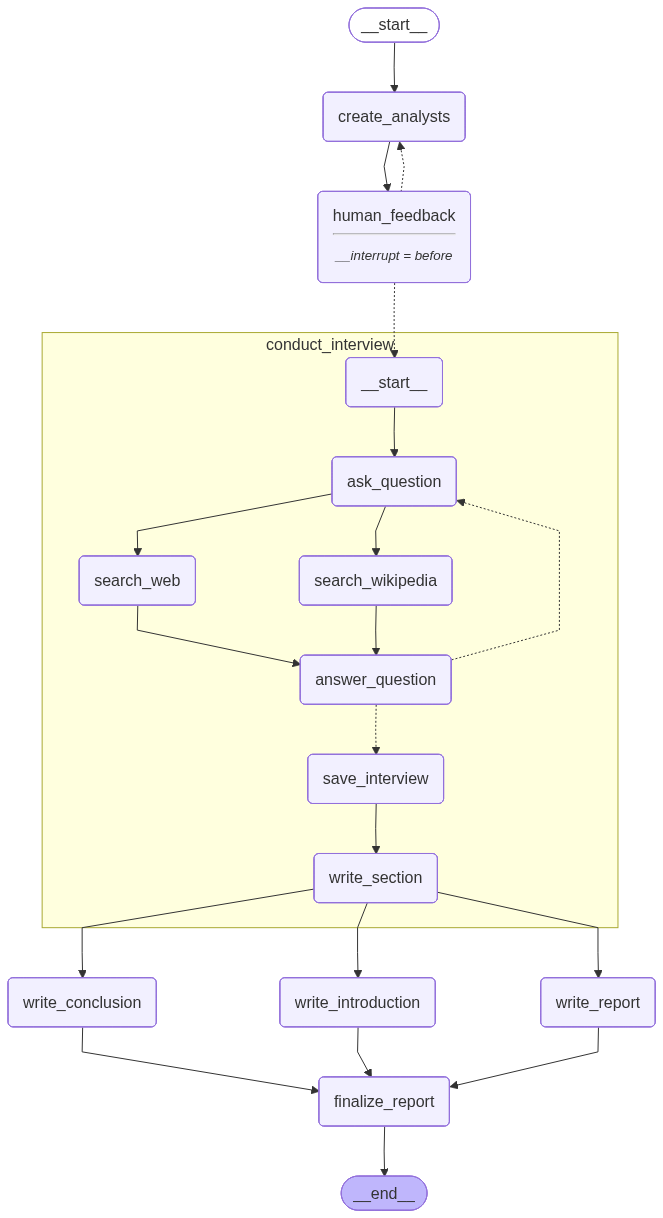

In [25]:
from langgraph.types import Send # updated in 1.0
def initiate_all_interviews(state: ResearchGraphState):
    """ 這是「map」步驟，我們在此使用 Send API 執行每一個訪談 sub-graph """    
    # 這個函式同時兼兩份差事，這是它看起來怪怪的原因：
    #   1. 人類還有意見 → 回傳字串 "create_analysts"，當普通 conditional edge 用（退回重做）
    #   2. 人類沒意見了 → 回傳一串 Send 物件，當 map 步驟用（平行開 N 場訪談）
    # 同一個 conditional edge 函式，回傳型別不同，行為天差地遠。

    # 檢查是否有 human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # 回到 create_analysts
        return "create_analysts"

    # 否則透過 Send() API 平行啟動訪談
    else:
        topic = state["topic"]
        # Send("conduct_interview", {...}) 讀作：
        #     「發一張工單給 conduct_interview 這個 node，工單內容是這個 dict。」
        #
        # 為什麼非用 Send 不可，不能用普通 edge？
        # 因為「要跑幾場訪談」是**執行時才知道的**——取決於 LLM 產生了幾位分析師、
        # 人類又追加了幾位。普通 edge 必須在 compile 當下就畫死，畫不出「N 條」。
        # Send 是唯一能在執行時決定「複製幾份、每份餵什麼」的機制。同 map-reduce 章。
        #
        # 類比：不是預先架三條固定產線，是把工單一張張發包給外包廠。
        # 有幾張單就開幾家外包，各做各的，做完把成品寄回同一個收件匣（sections）。
        #
        # ⚠️ 踩雷：Send 第二個參數餵的是**目標 node 的 state schema**，
        #    也就是 InterviewState（sub-graph 的），不是 ResearchGraphState。
        #    這裡只餵了 analyst + messages；max_num_turns 沒餵，
        #    所以每場訪談吃的是 route_messages 裡 state.get('max_num_turns', 2) 的預設 2。
        return [Send("conduct_interview", {"analyst": analyst,
                                           "messages": [HumanMessage(
                                               content=f"So you said you were writing an article on {topic}?"
                                           )
                                                       ]}) for analyst in state["analysts"]]

report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

def write_report(state: ResearchGraphState):
    # 完整的 section 集合
    sections = state["sections"]
    topic = state["topic"]

    # 把所有 section 串接在一起
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # 把這些 section 彙整成一份最終報告
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

def write_introduction(state: ResearchGraphState):
    # 完整的 section 集合
    sections = state["sections"]
    topic = state["topic"]

    # 把所有 section 串接在一起
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # 把這些 section 彙整成一份最終報告
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions]+[HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

def write_conclusion(state: ResearchGraphState):
    # 完整的 section 集合
    sections = state["sections"]
    topic = state["topic"]

    # 把所有 section 串接在一起
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # 把這些 section 彙整成一份最終報告
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

def finalize_report(state: ResearchGraphState):
    """ 這是「reduce」步驟，我們在此蒐集所有 section、把它們合併，並加以省思以撰寫前言／結論 """
    # ⚠️ docstring 說這裡是 reduce，但那是「敘事上的 reduce」。
    #    真正把 N 個 section 合起來的是 sections 欄位上的 operator.add，
    #    那件事在這個 node 被呼叫之前就已經默默做完了。
    #    這個 node 實際只是把 introduction / content / conclusion 三塊拼成一份文件。
    # 儲存完整的最終報告
    content = state["content"]
    if content.startswith("## Insights"):
        # ⚠️ 原始教材的 bug：str.strip("## Insights") 不是「去掉開頭這個字串」，
        #    而是「把頭尾所有落在 {#, 空格, I,n,s,i,g,h,t} 這組字元裡的字元通通剝掉」。
        #    所以標題後面接的字若剛好是這些字元（例如 "## Insights\n\nIn 2024..."），
        #    會被多咬掉幾個字。正解是 removeprefix("## Insights")。
        #    這裡照原樣保留不動，只點出來——上台講到這裡可以當個彩蛋。
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

# 加入 node 與 edge 
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
# ⚠️ 這一行是全章的縫合點，很容易一眼滑過去：
#    node 的內容直接是「另一張編譯好的 graph」。
#    這就是 sub-graph 章講的——一張 graph 可以整個當成一個 node 塞進來。
#    對主 graph 來說 conduct_interview 就只是個普通 node，
#    它完全不知道裡面有提問、雙路搜尋、迴圈、終止判斷這些事。
#
#    這裡 compile() 刻意不帶 checkpointer：sub-graph 會繼承主 graph 的，
#    所以整個系統共用一條 checkpoint 時間線（對照 cell 28 的獨立測試版）。
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# 邏輯
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
# 這條 edge 一次幹兩件事（因為 initiate_all_interviews 有兩種回傳型別）：
# 退回 create_analysts（人類還有意見），或 fan-out 到 N 個 conduct_interview。
# 清單裡的 ["create_analysts", "conduct_interview"] 一樣只是「可能去向」宣告，供畫圖用。
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
# 一個來源拉三條 edge → 三個寫作 node 平行跑。
# 它們敢平行，是因為各寫各的 key（content / introduction / conclusion），不會撞車。
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
# ⚠️ 這行的 list 語法很容易看漏，它跟上面三行意義完全不同：
#    來源是一個 **list**，讀作「這三個**全部**跑完，才准進 finalize_report」。
#    這是明確的 fan-in 等待點。
#    為什麼非寫不可？因為 finalize_report 要同時讀 introduction / content / conclusion，
#    少一塊就是 KeyError。這一行就是在保證「三塊都到齊了才動手拼」。
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)

# 編譯
# 跟 cell 10 一模一樣的 human-in-the-loop 配方，只是這次裝在真正的系統上：
# 停在 human_feedback 之前，讓人類核准分析師名單，才准放行。
#
# 為什麼偏偏卡在這個點？因為過了這關就是 N 場 LLM 訪談同時開跑，
# 每場又有多輪對話 + 多次搜尋。**錯的分析師名單 = 燒 N 倍的錢做白工。**
# human-in-the-loop 的落點原則：擋在最貴、最不可逆的動作之前。
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)
# xray=1 → 連 conduct_interview 裡面那張 sub-graph 也一起攤開來畫。
# 不加的話，conduct_interview 只會是圖上一個黑盒方塊。
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

讓我們針對 LangGraph 提出一個開放式的問題。

In [26]:
# 從這裡開始是完整系統的實跑。
# 操作流程跟 cell 11~16 一字不差（停 → update_state → stream(None) 續跑），
# 差別只在：這次 human_feedback 後面接的不是「重做或結束」，
# 而是「重做，或 fan-out 去跑 N 場訪談」。
# 前面練的那套手勢，原封不動搬到大魔王身上——這就是本章的重點。
# 輸入
max_analysts = 3 
topic = "The benefits of adopting LangGraph as an agent framework"
thread = {"configurable": {"thread_id": "1"}}

# 執行 graph 直到第一次中斷
for event in graph.stream({"topic":topic,
                           "max_analysts":max_analysts}, 
                          thread, 
                          stream_mode="values"):
    
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Emily Carter
Affiliation: Tech Innovators Inc.
Role: Technology Adoption Specialist
Description: Dr. Carter focuses on the strategic benefits of adopting new technologies like LangGraph. She is particularly interested in how LangGraph can streamline processes, improve efficiency, and provide a competitive edge to organizations. Her analysis often includes case studies and data-driven insights to support the adoption of innovative frameworks.
--------------------------------------------------
Name: Mr. Raj Patel
Affiliation: Data Security Solutions
Role: Cybersecurity Analyst
Description: Mr. Patel is concerned with the security implications of adopting new frameworks such as LangGraph. His focus is on understanding how LangGraph can enhance or compromise data security within an organization. He evaluates the framework's security features, potential vulnerabilities, and compliance with industry standards.
--------------------------------------------------
Name: Dr. Lisa Nguyen

In [27]:
# 現在我們更新 state，就好像我們是 human_feedback node
graph.update_state(thread, {"human_analyst_feedback": 
                                "Add in the CEO of gen ai native startup"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0ad478-2e3b-6372-8002-87845d0b55a4'}}

In [28]:
# 檢查
for event in graph.stream(None, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Emily Carter
Affiliation: Tech Innovators Inc.
Role: Technology Adoption Specialist
Description: Dr. Carter focuses on the strategic benefits of adopting new technologies like LangGraph. She is particularly interested in how LangGraph can streamline processes, improve efficiency, and provide a competitive edge to organizations. Her analysis often includes case studies and data-driven insights to support the adoption of innovative frameworks.
--------------------------------------------------
Name: Mr. Raj Patel
Affiliation: Data Security Solutions
Role: Cybersecurity Analyst
Description: Mr. Patel is concerned with the security implications of adopting new frameworks such as LangGraph. His focus is on understanding how LangGraph can enhance or compromise data security within an organization. He evaluates the framework's security features, potential vulnerabilities, and compliance with industry standards.
--------------------------------------------------
Name: Dr. Lisa Nguyen

In [29]:
# 確認我們滿意了
graph.update_state(thread, {"human_analyst_feedback": 
                            None}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0ad478-5521-6a86-8004-054b9bf88282'}}

In [30]:
# 繼續
# ⚠️ 這一步會跑很久：N 場訪談平行進行，每場裡面又有多輪 LLM 呼叫 + 兩路搜尋。
#    updates 模式讓你看得到 node 一個個亮起來。
#    注意 conduct_interview 只會出現一次（一個 node 名字），裡面三場訪談的細節
#    被 sub-graph 包住了看不到——想看內部得去 LangSmith trace（本 notebook 最後有連結）。
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

--Node--
conduct_interview
--Node--
conduct_interview
--Node--
conduct_interview
--Node--
write_conclusion
--Node--
write_introduction
--Node--
write_report
--Node--
finalize_report


In [31]:
from IPython.display import Markdown
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)

# LangGraph: Revolutionizing AI Agent Development

## Introduction

In the dynamic realm of AI development, LangGraph emerges as a transformative agent framework, offering unparalleled efficiency and capability enhancements. By adopting a graphical approach, LangGraph excels in managing complex, multi-step tasks, crucial for sophisticated AI agents. It integrates declarative and imperative APIs, supporting stateful, multi-agent applications with features like memory storage and fault tolerance. This framework not only reduces development time but also improves system quality, seamlessly integrating with large language models to enhance user experience. LangGraph's strategic advantages, including hybrid integration and open-source infrastructure, position it as a pivotal player in driving business growth and innovation across industries.

---



LangGraph emerges as a transformative agent framework in the AI landscape, offering significant benefits in enhancing AI efficiency, providing strategic advantages, and fostering business growth and innovation. Its graphical approach to constructing agent behaviors allows for the management of complex, multi-step tasks with backtracking and conditional branching, which is essential for developing sophisticated AI agents capable of operating autonomously and efficiently [1]. This graphical representation simplifies the design and implementation of complex workflows, reducing development time and improving system quality [4].

LangGraph's orchestration framework integrates both declarative and imperative APIs, supporting features such as short-term and long-term memory storage, human-in-the-loop processes, and fault tolerance. These capabilities are crucial for maintaining context and ensuring the reliability of AI workflows, making LangGraph a robust foundation for building stateful, multi-agent applications [2]. The framework's ability to integrate seamlessly with large language models (LLMs) further enhances its utility, enabling the creation of intelligent AI agents that can understand and generate human language, thus improving user experience and operational efficiency across various industries [5].

Strategically, LangGraph stands out for its ability to handle complex conditional logic and multi-step reasoning, making it ideal for applications requiring advanced state management and long-term system evolution. This positions LangGraph as a preferred choice for enterprises with experienced AI/ML engineers, supporting extended development cycles for sophisticated capabilities [2]. Its potential for hybrid integration with other frameworks allows organizations to create comprehensive, enterprise-ready AI solutions, facilitating gradual migration from existing implementations and risk mitigation through incremental adoption [2].

LangGraph's open-source nature and its foundation within the LangChain ecosystem enhance its appeal, providing a robust infrastructure for stateful agents and supporting integration with diverse data sources, APIs, and workflows. This flexibility and modularity make LangGraph not just a tool but a platform that others can build upon, enabling the deployment of multi-agent applications across a wide range of businesses [4].

In conclusion, LangGraph offers a unique set of tools and structures that empower businesses to harness the full potential of AI technologies. By integrating LangGraph into their operations, companies can enhance their product offerings, improve customer experiences, and maintain a competitive edge in the AI market. Its graphical approach, robust orchestration capabilities, and strategic advantages position LangGraph as a leading framework for optimizing AI systems' performance and driving innovation across industries.


---

## Conclusion

LangGraph emerges as a transformative agent framework in the AI landscape, offering significant advantages for optimizing AI systems. By employing a graphical approach, LangGraph enhances the efficiency and capability of AI models, particularly in managing complex, multi-step tasks. Its robust orchestration framework, integrating declarative and imperative APIs, supports stateful, multi-agent applications with features like memory storage and fault tolerance. This not only reduces development time but also improves system quality and operational efficiency. LangGraph's seamless integration with large language models further empowers businesses to innovate and maintain a competitive edge, making it a strategic asset for AI-driven growth and innovation.

## Sources
[1] https://community.latenode.com/t/what-are-the-main-advantages-of-choosing-langgraph-for-ai-agent-development/31000  
[2] https://blog.langchain.com/how-to-think-about-agent-frameworks/  
[3] https://blog.algoanalytics.com/2025/05/21/langgraph-the-framework-for-intelligent-ai-workflows/  
[4] https://medium.com/@ken_lin/langgraph-a-framework-for-building-stateful-multi-agent-llm-applications-a51d5eb68d03  
[5] https://www.rapidinnovation.io/post/ai-agents-in-langgraph  
[6] https://artizen.com/insights/thought-leadership/ai-agent-frameworks  
[7] https://www.leanware.co/insights/langchain-vs-langgraph-comparison  
[8] https://interviewkickstart.com/blogs/articles/langgraph-for-retail-ai-agent  
[9] https://medium.com/@takafumi.endo/langchain-why-its-the-foundation-of-ai-agent-development-in-the-enterprise-era-f082717c56d3  
[10] https://www.scalablepath.com/machine-learning/langgrap

我們可以看看這個 trace：

https://smith.langchain.com/public/2933a7bb-bcef-4d2d-9b85-cc735b22ca0c/r